# 05 — Chunking Strategy Evaluation

Picks the best chunking strategy using two tiers of metrics:

- **Tier 1 — Intrinsic quality** (free, local): size compliance, intrachunk cohesion, inter-chunk dissimilarity, overlap ratio, context completeness, category coverage.
- **Tier 2 — Retrieval quality** (cheap, ~$0.25 total): synthetic query generation per collection, then Hit Rate@5, MRR, Precision@5, NDCG@5.
- **Tier 2b — Score analysis** (free): score distributions, score gap, avg retrieved tokens.

RAGAS end-to-end metrics are intentionally deferred to **notebook 03** where retrieval methods are compared using the winning chunking strategy from here.

**Pre-requisites:** Run `02_build_index.ipynb` for each chunking strategy you want to evaluate.

In [1]:
# ── Environment & path setup ─────────────────────────────────────────────────
import os, sys
from pathlib import Path
from dotenv import load_dotenv

ROOT = Path.cwd().parent  # notebooks/ -> project root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

load_dotenv(ROOT / '.env')

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
QDRANT_URL     = os.getenv('QDRANT_URL', 'http://localhost:6333')
QDRANT_API_KEY = os.getenv('QDRANT_API_KEY', '')

print('OPENAI_API_KEY set:', bool(OPENAI_API_KEY))
print('QDRANT_URL       :', QDRANT_URL)

OPENAI_API_KEY set: True
QDRANT_URL       : https://38718a4e-130d-4ef7-be90-0c1893444e4c.us-east4-0.gcp.cloud.qdrant.io


In [2]:
# ── Clients ──────────────────────────────────────────────────────────────────
from openai import OpenAI
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer
import config

oai      = OpenAI(api_key=OPENAI_API_KEY)
qdrant   = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY or None)
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print('All clients ready.')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\User\.cursor\talkingtoai\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

All clients ready.


In [3]:
# ── Detect available collections ─────────────────────────────────────────────
from eval.eval_chunking import detect_available_collections

strategies = detect_available_collections(qdrant)

print(f'Available strategies ({len(strategies)}): {strategies}')

missing = [s for s in config.CHUNKING_STRATEGIES if s not in strategies]
if missing:
    print(f'\nNot yet indexed (will be skipped): {missing}')
    print('Re-run this notebook after building those collections in 02_build_index.ipynb.')

Available strategies (3): ['recursive', 'semantic', 'sentence_window']

Not yet indexed (will be skipped): ['parent_child', 'proposition']
Re-run this notebook after building those collections in 02_build_index.ipynb.


In [4]:
# ── Tier 1: Intrinsic metrics ────────────────────────────────────────────────
from eval.eval_chunking import run_intrinsic_eval

intrinsic_df = run_intrinsic_eval(strategies, qdrant, st_model)
intrinsic_df


[Tier 1] recursive — loading from 'hr_rag_recursive'...
  1,692 indexable chunks loaded.
  Computing intrachunk cohesion...
  Computing inter-chunk dissimilarity...
  Done: ICC=0.5411  dissim=0.791  size_comp=0.935

[Tier 1] semantic — loading from 'hr_rag_semantic'...
  1,007 indexable chunks loaded.
  Computing intrachunk cohesion...
  Computing inter-chunk dissimilarity...
  Done: ICC=0.4824  dissim=0.7837  size_comp=0.5362

[Tier 1] sentence_window — loading from 'hr_rag_sentence_window'...
  4,616 indexable chunks loaded.
  Computing intrachunk cohesion...
  Computing inter-chunk dissimilarity...
  Done: ICC=None  dissim=0.8156  size_comp=0.115


,strategy,total_chunks,token_mean,token_median,token_std,token_min,token_max,size_compliance,icc,dissimilarity,overlap_ratio,context_completeness,categories_covered
0,recursive,1692,302.1,360.0,104.4,34,400,0.9350,0.5411,0.7910,NaN,None,11
1,semantic,1007,468.8,186.0,1590.4,14,40552,0.5362,0.4824,0.7837,NaN,None,11
2,sentence_window,4616,68.1,44.0,124.2,7,4575,0.1150,NaN,0.8156,0.0601,None,11


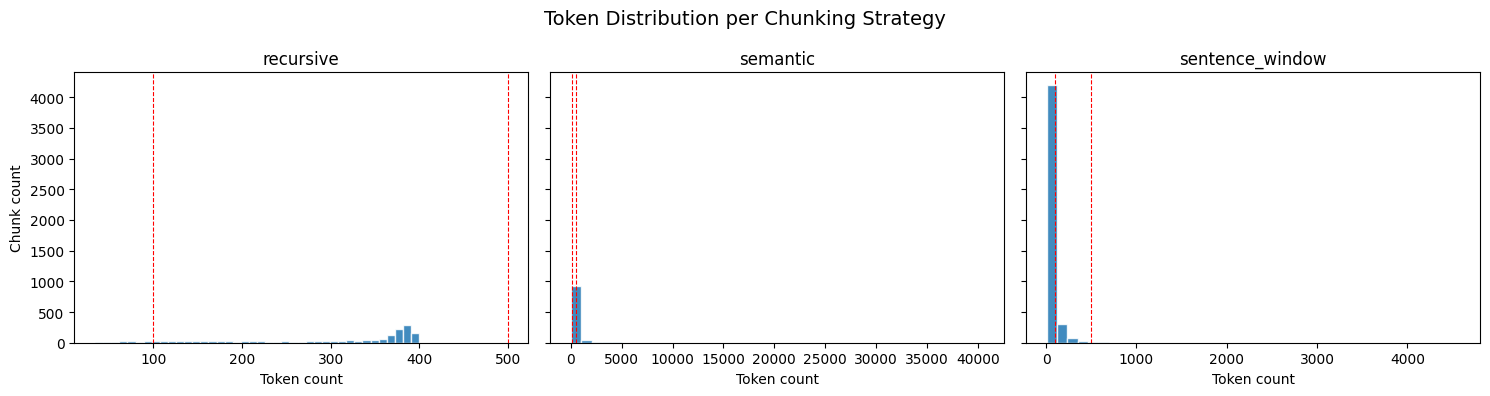

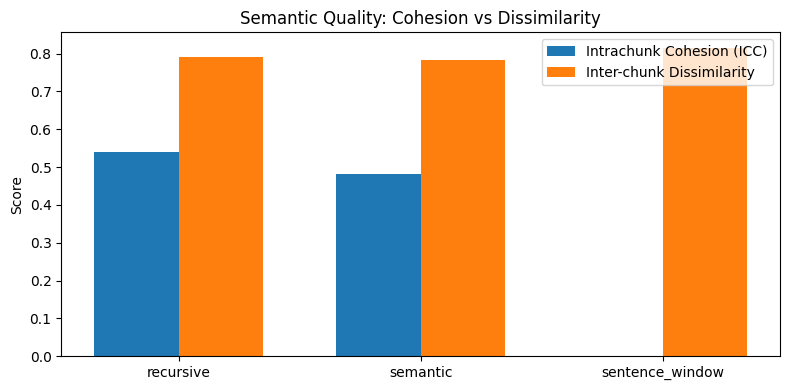

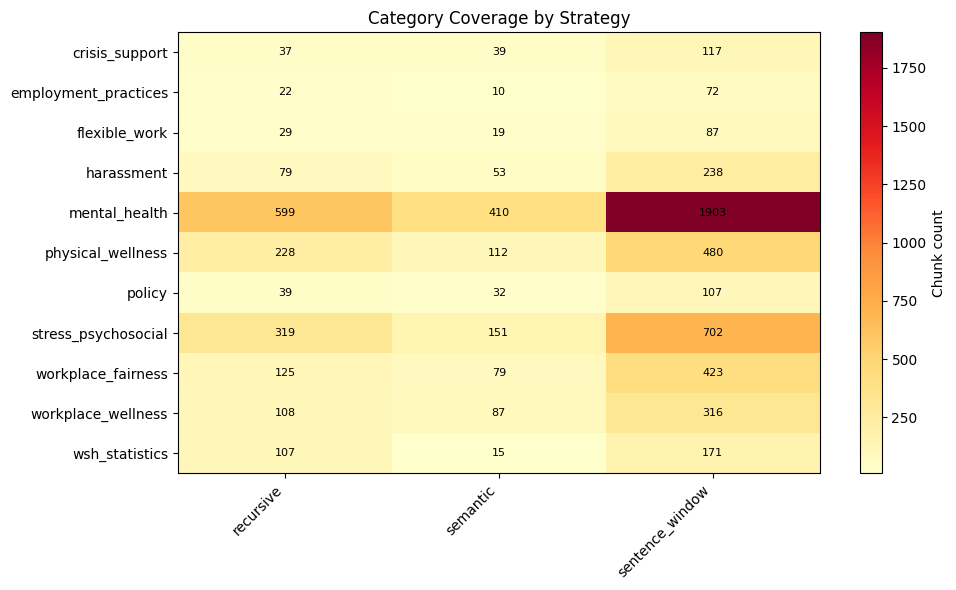

In [6]:
# ── Tier 1: Visualisations ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from eval.eval_chunking import load_chunks_from_qdrant

fig, axes = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4), sharey=True)
if len(strategies) == 1:
    axes = [axes]

for ax, strategy in zip(axes, strategies):
    collection = f'{config.COLLECTION_PREFIX}_{strategy}'
    chunks = load_chunks_from_qdrant(qdrant, collection)
    indexable = [c for c in chunks if c.get('strategy') != 'parent']
    tokens = [c.get('token_count', 0) for c in indexable]
    ax.hist(tokens, bins=40, edgecolor='white', alpha=0.85)
    ax.set_title(strategy)
    ax.set_xlabel('Token count')
    ax.axvline(100, color='red', linestyle='--', linewidth=0.8, label='min=100')
    ax.axvline(500, color='red', linestyle='--', linewidth=0.8, label='max=500')

axes[0].set_ylabel('Chunk count')
fig.suptitle('Token Distribution per Chunking Strategy', fontsize=14)
plt.tight_layout()
plt.show()

# ── ICC + Dissimilarity bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(strategies))
w = 0.35

icc_vals = intrinsic_df['icc'].fillna(0).values
dis_vals = intrinsic_df['dissimilarity'].fillna(0).values

ax.bar(x - w/2, icc_vals, w, label='Intrachunk Cohesion (ICC)')
ax.bar(x + w/2, dis_vals, w, label='Inter-chunk Dissimilarity')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylabel('Score')
ax.set_title('Semantic Quality: Cohesion vs Dissimilarity')
ax.legend()
plt.tight_layout()
plt.show()

# ── Category coverage heatmap ────────────────────────────────────────────────
from eval.eval_chunking import compute_category_distribution
import pandas as pd

cat_data = {}
for strategy in strategies:
    collection = f'{config.COLLECTION_PREFIX}_{strategy}'
    chunks = load_chunks_from_qdrant(qdrant, collection)
    indexable = [c for c in chunks if c.get('strategy') != 'parent']
    cat_data[strategy] = compute_category_distribution(indexable)

cat_df = pd.DataFrame(cat_data).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(cat_df.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(cat_df.columns)))
ax.set_xticklabels(cat_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cat_df.index)))
ax.set_yticklabels(cat_df.index)
for i in range(len(cat_df.index)):
    for j in range(len(cat_df.columns)):
        ax.text(j, i, str(cat_df.iloc[i, j]), ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Chunk count')
ax.set_title('Category Coverage by Strategy')
plt.tight_layout()
plt.show()

In [7]:
# ── Tier 2: Generate or load synthetic queries ───────────────────────────────
import os
from eval.eval_chunking import (
    generate_synthetic_queries, load_synthetic_queries,
    load_chunks_from_qdrant,
)

N_QUERIES = 100  # queries per collection

synth_queries = {}
for strategy in strategies:
    query_path = os.path.join(config.SYNTH_QUERIES_DIR, f'{strategy}.json')
    if os.path.exists(query_path):
        print(f'{strategy}: loading cached queries from {query_path}')
        synth_queries[strategy] = load_synthetic_queries(query_path)
    else:
        print(f'{strategy}: generating {N_QUERIES} synthetic queries...')
        collection = f'{config.COLLECTION_PREFIX}_{strategy}'
        chunks = load_chunks_from_qdrant(qdrant, collection)
        indexable = [c for c in chunks if c.get("strategy") != "parent"]
        synth_queries[strategy] = generate_synthetic_queries(
            indexable, oai, n=N_QUERIES, save_path=query_path,
        )
    print(f'  {strategy}: {len(synth_queries[strategy])} queries ready.\n')

recursive: generating 100 synthetic queries...
  Generating 100 synthetic queries...
  [001/100] physical_wellness... ok
  [002/100] physical_wellness... ok
  [003/100] physical_wellness... ok
  [004/100] physical_wellness... ok
  [005/100] physical_wellness... ok
  [006/100] physical_wellness... ok
  [007/100] physical_wellness... ok
  [008/100] physical_wellness... ok
  [009/100] physical_wellness... ok
  [010/100] policy... ok
  [011/100] policy... ok
  [012/100] policy... ok
  [013/100] policy... ok
  [014/100] policy... ok
  [015/100] policy... ok
  [016/100] policy... ok
  [017/100] policy... ok
  [018/100] policy... ok
  [019/100] workplace_fairness... ok
  [020/100] workplace_fairness... ok
  [021/100] workplace_fairness... ok
  [022/100] workplace_fairness... ok
  [023/100] workplace_fairness... ok
  [024/100] workplace_fairness... ok
  [025/100] workplace_fairness... ok
  [026/100] workplace_fairness... ok
  [027/100] workplace_fairness... ok
  [028/100] crisis_support... ok


In [8]:
# ── Tier 2: Retrieval metrics ────────────────────────────────────────────────
import pandas as pd
from eval.eval_chunking import run_retrieval_eval

retrieval_rows = []
raw_scores = {}  # for visualisations

for strategy in strategies:
    print(f'\n── {strategy} ──')
    result = run_retrieval_eval(
        synth_queries[strategy], strategy, oai, qdrant, top_k=config.TOP_K,
    )
    raw_scores[strategy] = {
        'top1': result.pop('_all_top1_scores', []),
        'topk': result.pop('_all_topk_scores', []),
    }
    retrieval_rows.append(result)
    print(f'  Hit Rate@5={result["hit_rate_at_5"]}  MRR={result["mrr"]}  '
          f'NDCG@5={result["ndcg_at_5"]}  AvgCtxTokens={result["avg_context_tokens"]}')

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df


── recursive ──
    Retrieving [1/100]...
    Retrieving [20/100]...
    Retrieving [40/100]...
    Retrieving [60/100]...
    Retrieving [80/100]...
    Retrieving [100/100]...
  Hit Rate@5=0.76  MRR=0.6452  NDCG@5=0.674  AvgCtxTokens=1519.0

── semantic ──
    Retrieving [1/100]...
    Retrieving [20/100]...
    Retrieving [40/100]...
    Retrieving [60/100]...
    Retrieving [80/100]...
    Retrieving [100/100]...
  Hit Rate@5=0.86  MRR=0.7207  NDCG@5=0.7558  AvgCtxTokens=2642.8

── sentence_window ──
    Retrieving [1/100]...
    Retrieving [20/100]...
    Retrieving [40/100]...
    Retrieving [60/100]...
    Retrieving [80/100]...
    Retrieving [100/100]...
  Hit Rate@5=0.75  MRR=0.6382  NDCG@5=0.6661  AvgCtxTokens=1355.8


,strategy,hit_rate_at_5,mrr,precision_at_5,ndcg_at_5,mean_top1_score,mean_score_gap,avg_retrieved_tokens,avg_context_tokens
0,recursive,0.76,0.6452,0.152,0.6740,0.6800,0.1067,1519.0,1519.0
1,semantic,0.86,0.7207,0.172,0.7558,0.6644,0.1439,2642.8,2642.8
2,sentence_window,0.75,0.6382,0.150,0.6661,0.7371,0.1431,304.6,1355.8


C:\Users\User\AppData\Local\Temp\ipykernel_21016\3343803367.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=strategies, patch_artist=True)


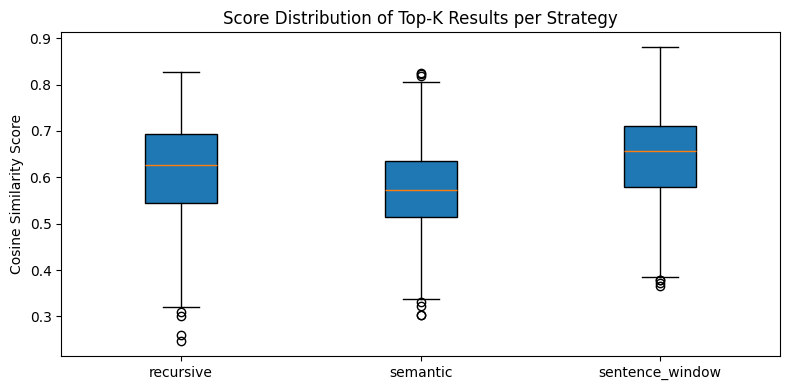

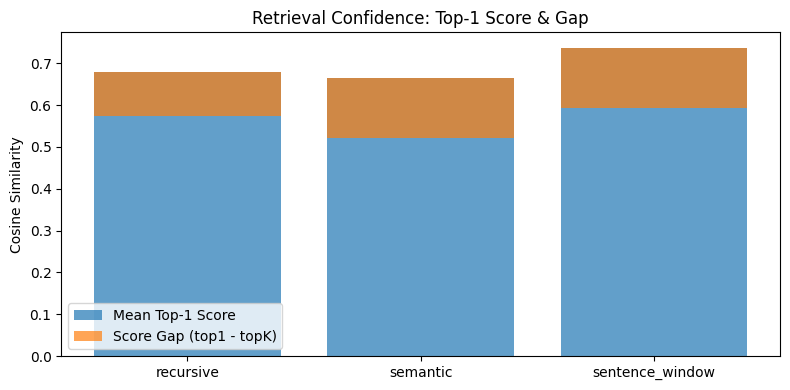

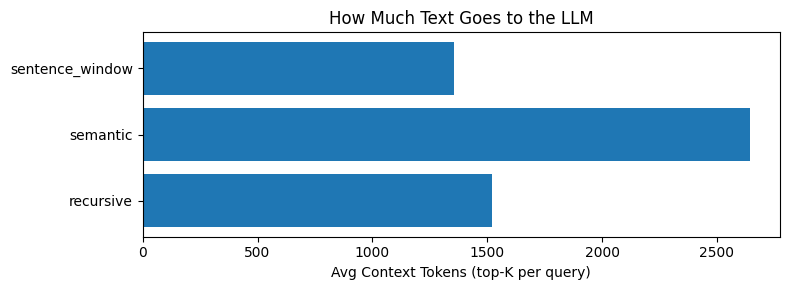

In [9]:
# ── Tier 2b: Score analysis ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ── Box plots of top-K score distributions ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
data = [raw_scores[s]['topk'] for s in strategies]
ax.boxplot(data, labels=strategies, patch_artist=True)
ax.set_ylabel('Cosine Similarity Score')
ax.set_title('Score Distribution of Top-K Results per Strategy')
plt.tight_layout()
plt.show()

# ── Score gap chart ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(strategies))
gaps = retrieval_df['mean_score_gap'].fillna(0).values
top1 = retrieval_df['mean_top1_score'].fillna(0).values

ax.bar(x, top1, label='Mean Top-1 Score', alpha=0.7)
ax.bar(x, gaps, bottom=[t - g for t, g in zip(top1, gaps)], label='Score Gap (top1 - topK)', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(strategies)
ax.set_ylabel('Cosine Similarity')
ax.set_title('Retrieval Confidence: Top-1 Score & Gap')
ax.legend()
plt.tight_layout()
plt.show()

# ── Avg context tokens ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(strategies, retrieval_df['avg_context_tokens'].values)
ax.set_xlabel('Avg Context Tokens (top-K per query)')
ax.set_title('How Much Text Goes to the LLM')
plt.tight_layout()
plt.show()

In [10]:
# ── Strategy-specific risk flags ─────────────────────────────────────────────
import pandas as pd

risks = {
    'recursive':       {'risk': 'Cuts mid-sentence/concept',
                        'check': 'ICC score (low = bad boundaries)'},
    'semantic':        {'risk': 'Over-splits or under-splits',
                        'check': 'Chunk size variance, ICC spread'},
    'sentence_window': {'risk': 'Redundant retrieval',
                        'check': 'Overlap ratio, dedup hit rate'},
    'parent_child':    {'risk': 'Child chunks too small to embed well',
                        'check': 'Child size distribution, context completeness'},
    'proposition':     {'risk': 'LLM extraction errors',
                        'check': 'Context completeness, proposition length'},
}

risk_rows = []
for strategy in strategies:
    r = risks.get(strategy, {'risk': '-', 'check': '-'})
    row = intrinsic_df[intrinsic_df['strategy'] == strategy].iloc[0]

    flags = []
    if row.get('icc') is not None and row['icc'] < 0.65:
        flags.append(f'Low ICC ({row["icc"]:.3f})')
    if row.get('size_compliance') is not None and row['size_compliance'] < 0.5:
        flags.append(f'Low size compliance ({row["size_compliance"]:.2f})')
    if row.get('overlap_ratio') is not None and row['overlap_ratio'] > 0.6:
        flags.append(f'High overlap ({row["overlap_ratio"]:.2f})')
    if row.get('context_completeness') is not None and row['context_completeness'] < 0.8:
        flags.append(f'Low context completeness ({row["context_completeness"]:.2f})')

    risk_rows.append({
        'strategy':     strategy,
        'known_risk':   r['risk'],
        'what_to_check': r['check'],
        'flags':        '; '.join(flags) if flags else 'None',
    })

risk_df = pd.DataFrame(risk_rows)
print('Strategy Risk Flags:')
print(risk_df.to_string(index=False))

Strategy Risk Flags:
       strategy                  known_risk                    what_to_check                      flags
      recursive   Cuts mid-sentence/concept ICC score (low = bad boundaries)            Low ICC (0.541)
       semantic Over-splits or under-splits  Chunk size variance, ICC spread            Low ICC (0.482)
sentence_window         Redundant retrieval    Overlap ratio, dedup hit rate Low size compliance (0.12)


In [11]:
# ── Combined ranking + recommendation ────────────────────────────────────────
from eval.eval_chunking import print_chunk_eval_summary

retrieval_clean = retrieval_df.drop(
    columns=[c for c in retrieval_df.columns if c.startswith('_')], errors='ignore'
)
merged = intrinsic_df.merge(retrieval_clean, on='strategy', how='outer')

print_chunk_eval_summary(merged)

# Save to CSV
from pathlib import Path
Path(config.CHUNK_EVAL_PATH).parent.mkdir(parents=True, exist_ok=True)
merged.to_csv(config.CHUNK_EVAL_PATH, index=False)
print(f'\nResults saved to {config.CHUNK_EVAL_PATH}')

print('\n\nNext step: take the winning strategy to notebook 03 (03_run_eval.ipynb).')
print('Set chunking_strategies=["<winner>"] and run the RAGAS grid across retrieval methods.')


CHUNKING STRATEGY EVALUATION SUMMARY
       strategy  total_chunks  hit_rate_at_5    mrr  ndcg_at_5    icc  size_compliance  dissimilarity  mean_top1_score  mean_score_gap  avg_context_tokens
      recursive          1692           0.76 0.6452     0.6740 0.5411           0.9350         0.7910           0.6800          0.1067              1519.0
       semantic          1007           0.86 0.7207     0.7558 0.4824           0.5362         0.7837           0.6644          0.1439              2642.8
sentence_window          4616           0.75 0.6382     0.6661    NaN           0.1150         0.8156           0.7371          0.1431              1355.8

Recommended strategy: semantic
  Composite score : 0.7205
  hit_rate_at_5       : 0.8600
  mrr                 : 0.7207
  ndcg_at_5           : 0.7558
  icc                 : 0.4824
  size_compliance     : 0.5362

Results saved to C:\Users\User\.cursor\talkingtoai\results\chunk_eval_results.csv


Next step: take the winning strategy to not